In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../fourier/')
path.append('../../signals/')

import stft
import signals as sg

In [3]:
from scipy.signal import periodogram

## Oscillation amplitude increases at a time point

In [4]:

t_before = 255 # s
t_inject = t_before
t_after = 839 # s
freq = 0.02
fs = 2

A_before = 1
A_after = 1.4

_, x_before = sg.cosine(t_before, freq, fs, amplitude=A_before)
_, x_after = sg.cosine(t_after, freq, fs, amplitude=A_after)

x = np.hstack([x_before, x_after]) 
x += np.random.randn(x.size)
t = np.arange(x.size)*(1/fs)

In [5]:
x_norm = x / np.std(x)

In [6]:

window_size = int((t_inject/1.95)*fs) # half injection time
p = stft.windowed_periodogram(x, fs, window_size=window_size)

(0.0, 0.1)

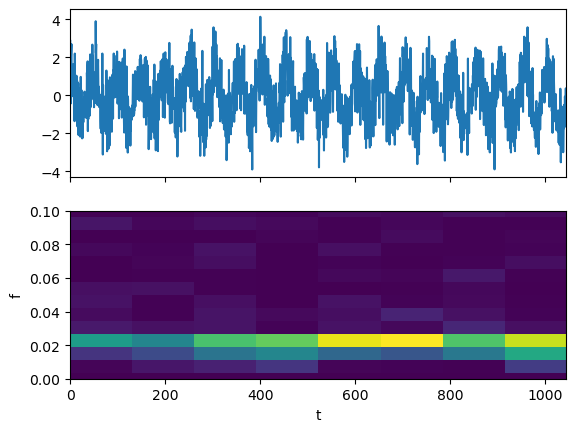

In [7]:
f, (ax,ax1) = plt.subplots(2,1,sharex=True)
ax.plot(t,x)
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)

# Oscillation amplitude constant, but signal mean changes at a point

### Absolute signal

In [8]:

t_duration = 1102
freq = 0.02
fs = 2
A = 1
bkg = 30
k = 0.01

t,x = sg.cosine(t_duration, freq, fs, A)
x = bkg + k*t + x

In [16]:

window_size = int((t_inject)*fs) # half injection time
p = stft.windowed_periodogram(x, fs, window_size=window_size, detrend='linear')

(0.0, 0.1)

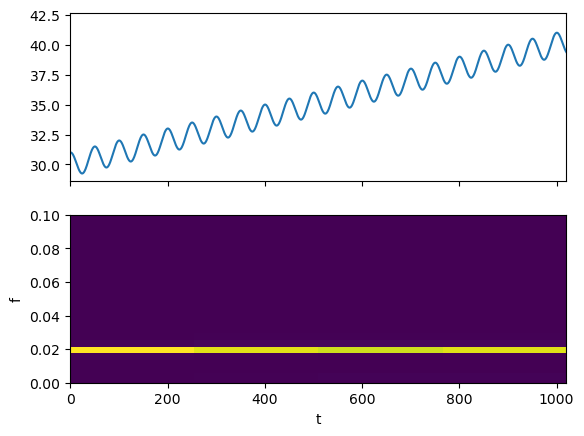

In [17]:
f, (ax,ax1) = plt.subplots(2,1,sharex=True)
ax.plot(t,x)
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)

### Normalized

In [18]:
from scipy.ndimage import gaussian_filter1d

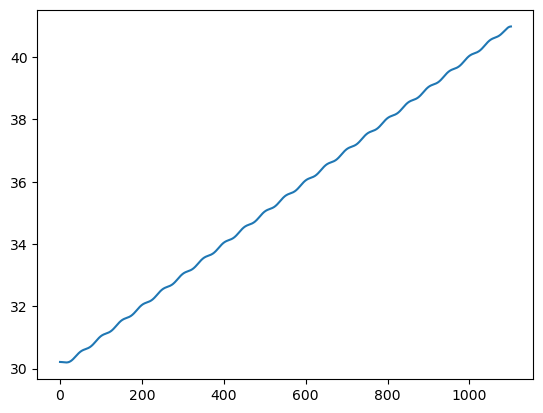

In [19]:
mn = gaussian_filter1d(x, 40)
plt.plot(t, mn)

In [20]:
x_norm = x / mn

In [24]:
p = stft.windowed_periodogram(x_norm, fs, window_size=window_size)

(0.0, 0.1)

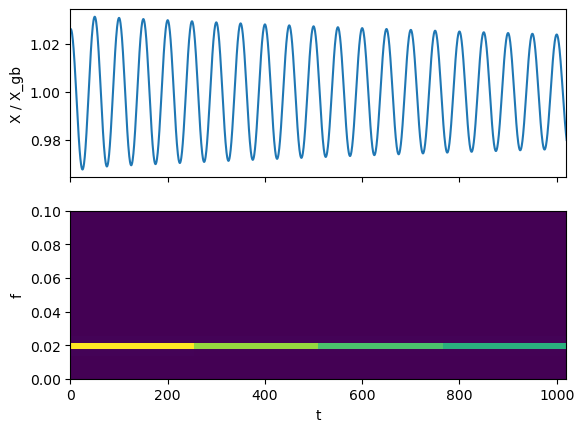

In [25]:
f, (ax,ax1) = plt.subplots(2,1,sharex=True)
ax.plot(t,x_norm)
ax.set_ylabel('X / X_gb')
p.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)